# 04 — Before vs After

**Project:** Marketing Attribution & Systems-Integration Analysis

## Purpose

Notebook 02 measured the naive join: 0% match, \$11.1M of spend and \$10.0M of revenue
unreconciled. Notebook 03 built and validated a semantic crosswalk. This notebook puts the two
states side by side and asks what the fix actually bought.

## The one rule this notebook has to follow

A before/after chart is the most persuasive artifact in the project and the easiest place in it
to lie. Two specific temptations:

1. **Moving the denominator.** If "before" divides by one thing and "after" divides by another,
   the improvement is partly arithmetic. Both baseline rows were written with denominators
   fixed before any join ran, and the assertion below re-checks that.
2. **Cropping the remainder.** A bar going 0% → 79.3% invites the reader to see a solved
   problem. The unreconciled portion is drawn on the same axis, at the same scale, in every
   chart here.

The honest headline is not "we fixed attribution." It is "one of five root causes was
addressable, and here is precisely how much of the gap that closed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
sns.set_theme(style='whitegrid')

before = pd.read_csv('../output/baseline_naive.csv')
after  = pd.read_csv('../output/baseline_reconciled.csv')

assert list(before.columns) == list(after.columns), "schema drift between the two baseline rows"
assert np.isclose(before['ad_spend_total'].iloc[0], after['ad_spend_total'].iloc[0]), \
    "ad spend denominator differs between before and after — comparison would be invalid"
assert np.isclose(before['crm_revenue_total'].iloc[0], after['crm_revenue_total'].iloc[0]), \
    "crm revenue denominator differs between before and after — comparison would be invalid"

comparison = pd.concat([before, after], ignore_index=True)

print("Denominators verified identical across both states.")
print(f"  ad spend total:    ${comparison['ad_spend_total'].iloc[0]:>14,.2f}")
print(f"  crm revenue total: ${comparison['crm_revenue_total'].iloc[0]:>14,.2f}")
print()
comparison[['stage', 'matched_categories', 'category_match_rate',
            'ad_spend_coverage', 'crm_revenue_coverage']]

Denominators verified identical across both states.
  ad spend total:    $ 11,108,749.09
  crm revenue total: $ 10,005,534.00



,stage,matched_categories,category_match_rate,ad_spend_coverage,crm_revenue_coverage
0,naive_join,0,0.0,0.000000,0.000000
1,reconciled_crosswalk,4,0.8,0.793228,0.525306


---

## Step 1 — The headline numbers

In [2]:
AD_TOTAL  = comparison['ad_spend_total'].iloc[0]
CRM_TOTAL = comparison['crm_revenue_total'].iloc[0]

b, a = comparison.iloc[0], comparison.iloc[1]

summary = pd.DataFrame([
    {'metric': 'Ads categories matched',
     'before': f"{int(b.matched_categories)} of {int(b.ads_categories)}",
     'after':  f"{int(a.matched_categories)} of {int(a.ads_categories)}",
     'change': f"+{int(a.matched_categories - b.matched_categories)}"},
    {'metric': 'Ad spend reconciled',
     'before': f"${b.ad_spend_matched:,.0f}  ({b.ad_spend_coverage:.1%})",
     'after':  f"${a.ad_spend_matched:,.0f}  ({a.ad_spend_coverage:.1%})",
     'change': f"+{(a.ad_spend_coverage - b.ad_spend_coverage) * 100:.1f}pp"},
    {'metric': 'CRM revenue reconciled',
     'before': f"${b.crm_revenue_matched:,.0f}  ({b.crm_revenue_coverage:.1%})",
     'after':  f"${a.crm_revenue_matched:,.0f}  ({a.crm_revenue_coverage:.1%})",
     'change': f"+{(a.crm_revenue_coverage - b.crm_revenue_coverage) * 100:.1f}pp"},
    {'metric': 'Ad spend STILL unreconciled',
     'before': f"${AD_TOTAL - b.ad_spend_matched:,.0f}",
     'after':  f"${AD_TOTAL - a.ad_spend_matched:,.0f}",
     'change': f"-${(a.ad_spend_matched - b.ad_spend_matched):,.0f}"},
    {'metric': 'CRM revenue STILL unreconciled',
     'before': f"${CRM_TOTAL - b.crm_revenue_matched:,.0f}",
     'after':  f"${CRM_TOTAL - a.crm_revenue_matched:,.0f}",
     'change': f"-${(a.crm_revenue_matched - b.crm_revenue_matched):,.0f}"},
]).set_index('metric')

print("=" * 84)
print("BEFORE (naive string join)  vs  AFTER (validated semantic crosswalk)")
print("=" * 84)
summary

BEFORE (naive string join)  vs  AFTER (validated semantic crosswalk)


,before,after,change
metric,,,
Ads categories matched,0 of 5,4 of 5,+4
Ad spend reconciled,$0 (0.0%),"$8,811,771 (79.3%)",+79.3pp
CRM revenue reconciled,$0 (0.0%),"$5,255,965 (52.5%)",+52.5pp
Ad spend STILL unreconciled,"$11,108,749","$2,296,979","-$8,811,771"
CRM revenue STILL unreconciled,"$10,005,534","$4,749,569","-$5,255,965"


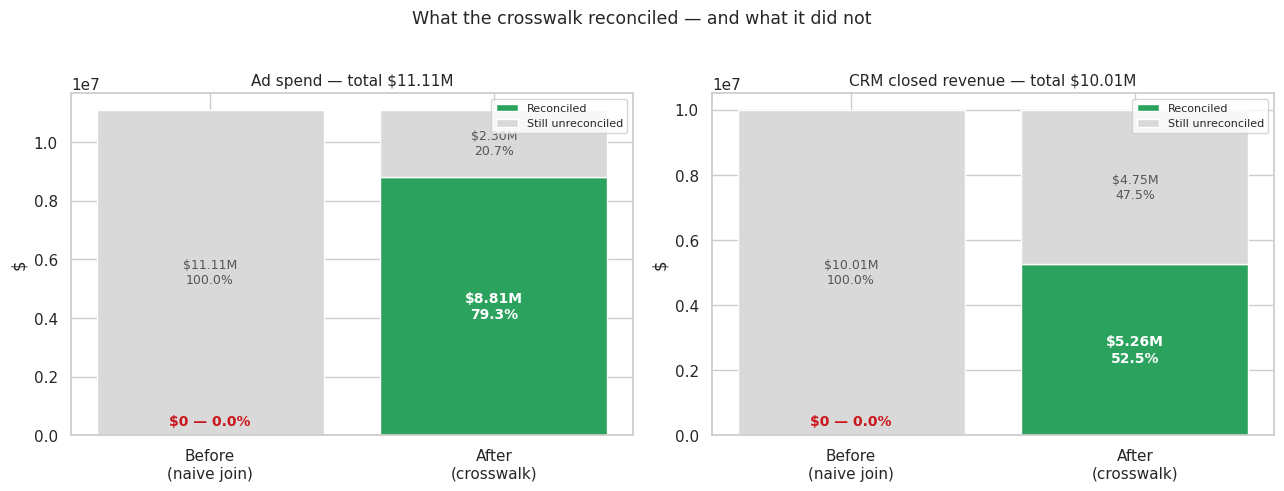

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, (label, total, key) in zip(axes, [
        ('Ad spend', AD_TOTAL, 'ad_spend_matched'),
        ('CRM closed revenue', CRM_TOTAL, 'crm_revenue_matched')]):

    states = ['Before\n(naive join)', 'After\n(crosswalk)']
    matched = [b[key], a[key]]
    remainder = [total - m for m in matched]

    ax.bar(states, matched, color='#2ca25f', label='Reconciled')
    ax.bar(states, remainder, bottom=matched, color='#d9d9d9', label='Still unreconciled')

    for i, m in enumerate(matched):
        pct = m / total
        if m > 0:
            ax.text(i, m / 2, f'${m/1e6:.2f}M\n{pct:.1%}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        else:
            ax.text(i, total * 0.02, '$0 — 0.0%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='#cb181d')
        ax.text(i, m + remainder[i] / 2, f'${remainder[i]/1e6:.2f}M\n{1-pct:.1%}',
                ha='center', va='center', fontsize=9, color='#555555')

    ax.set_ylabel('$')
    ax.set_title(f'{label} — total ${total/1e6:.2f}M', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('What the crosswalk reconciled — and what it did not',
             fontsize=12.5, y=1.02)
plt.tight_layout()
plt.show()

**Read the grey.** After the fix, \$2.30M of spend and \$4.75M of revenue remain outside the
comparison. The green blocks are the deliverable; the grey blocks are the recommendation in
the README.

The asymmetry between the two panels is the structural point from notebook 03: the ad platform
buys against 5 categories, the CRM describes 10. Spend reconciles well because almost all of it
targets industries the CRM recognises. Revenue reconciles worse because much of the business
sells into sectors marketing never advertised into at all.

---

## Step 2 — Metrics that did not exist before

The clearest way to express what changed is not a coverage percentage — it is the set of
numbers that were literally uncomputable in the "before" state.

Every metric below requires values from **both** systems on one row. Under the naive join no
such row existed, so each was undefined: not zero, not null, but unanswerable.

In [4]:
ads = pd.read_parquet('../data/clean/ads_typed.parquet')
crm = pd.read_parquet('../data/clean/crm_enriched.parquet')
crosswalk = pd.read_csv('../output/industry_crosswalk.csv')

active = crosswalk[crosswalk['ads_industry'].notna() & crosswalk['crm_sector'].notna()]

ads_agg = ads.groupby('industry', as_index=False).agg(
    ad_spend=('ad_spend', 'sum'),
    ads_reported_revenue=('revenue', 'sum'),
    conversions=('conversions', 'sum'),
)

won = crm[crm['deal_stage'] == 'Won']
crm_agg = won.groupby('sector', as_index=False).agg(
    crm_revenue=('close_value', 'sum'),
    deals_won=('opportunity_id', 'count'),
).merge(active[['ads_industry', 'crm_sector']],
        left_on='sector', right_on='crm_sector', how='inner')

crm_agg = crm_agg.groupby('ads_industry', as_index=False).agg(
    crm_revenue=('crm_revenue', 'sum'), deals_won=('deals_won', 'sum'))

m = ads_agg.merge(crm_agg, left_on='industry', right_on='ads_industry',
                  how='inner', validate='one_to_one')

m['crm_rev_per_ad_dollar'] = m['crm_revenue'] / m['ad_spend']
m['ad_spend_per_won_deal'] = m['ad_spend'] / m['deals_won']
m['platform_roas']         = m['ads_reported_revenue'] / m['ad_spend']

out = m[['industry', 'ad_spend', 'crm_revenue', 'deals_won',
         'crm_rev_per_ad_dollar', 'ad_spend_per_won_deal', 'platform_roas']]

print("Cross-system metrics — undefined under the naive join, computable now")
print("(all four rows required a joined ads+CRM record, which did not previously exist)\n")
print(out.to_string(index=False, formatters={
    'ad_spend': '${:,.0f}'.format, 'crm_revenue': '${:,.0f}'.format,
    'deals_won': '{:,}'.format,
    'crm_rev_per_ad_dollar': '${:.2f}'.format,
    'ad_spend_per_won_deal': '${:,.0f}'.format,
    'platform_roas': '{:.2f}x'.format}))

Cross-system metrics — undefined under the naive join, computable now
(all four rows required a joined ads+CRM record, which did not previously exist)

  industry   ad_spend crm_revenue deals_won crm_rev_per_ad_dollar ad_spend_per_won_deal platform_roas
E-commerce $1,923,987  $1,867,528       799                 $0.97                $2,408         5.01x
   Fintech $2,271,538    $950,908       375                 $0.42                $6,057         4.48x
Healthcare $2,258,684  $1,359,595       592                 $0.60                $3,815         4.84x
      SaaS $2,357,562  $1,077,934       450                 $0.46                $5,239         5.04x


### The two systems still disagree — now quantifiably

Look at the last two numeric columns together. `platform_roas` is what the ad platform reports.
`crm_rev_per_ad_dollar` is closed-won revenue divided by the spend now mapped to it.

Both are revenue-per-ad-dollar. They differ by roughly an order of magnitude.

REVENUE PER AD DOLLAR — THE SAME QUESTION, TWO SYSTEMS
  Platform-reported (ads `revenue` column):    4.84x
  CRM-anchored (closed-won `close_value`):     0.60x
  Divergence:                                   8.1x

Note: computed over the 4 RECONCILED industries only, which is why the platform
figure is 4.84x here rather than the 4.88x all-industry blend in notebook 02.
EdTech is excluded because it has no CRM counterpart to compare against.


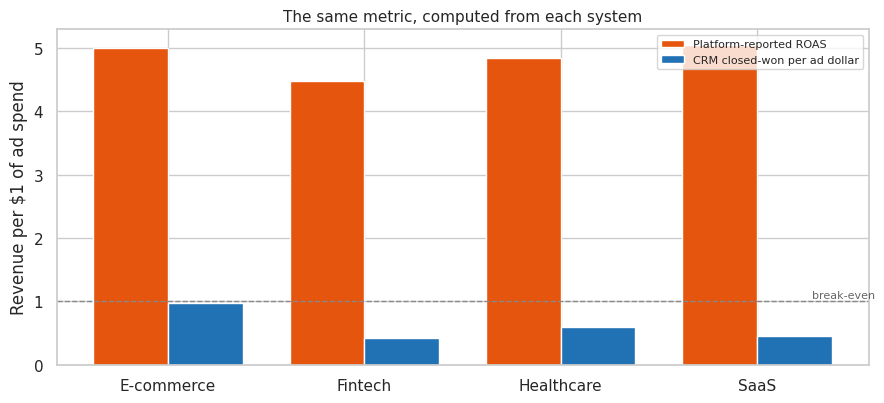

In [5]:
blended_platform = m['ads_reported_revenue'].sum() / m['ad_spend'].sum()
blended_crm      = m['crm_revenue'].sum() / m['ad_spend'].sum()

print("=" * 70)
print("REVENUE PER AD DOLLAR — THE SAME QUESTION, TWO SYSTEMS")
print("=" * 70)
print(f"  Platform-reported (ads `revenue` column):  {blended_platform:>6.2f}x")
print(f"  CRM-anchored (closed-won `close_value`):   {blended_crm:>6.2f}x")
print(f"  Divergence:                                {blended_platform / blended_crm:>6.1f}x")
print("=" * 70)
print()
print("Note: computed over the 4 RECONCILED industries only, which is why the platform")
print("figure is 4.84x here rather than the 4.88x all-industry blend in notebook 02.")
print("EdTech is excluded because it has no CRM counterpart to compare against.")

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(m))
w = 0.38
mm = m.sort_values('industry')
ax.bar(x - w/2, mm['platform_roas'], w, label='Platform-reported ROAS', color='#e6550d')
ax.bar(x + w/2, mm['crm_rev_per_ad_dollar'], w, label='CRM closed-won per ad dollar',
       color='#2171b5')
ax.axhline(1.0, color='#888888', ls='--', lw=1)
ax.text(len(m) - 0.4, 1.05, 'break-even', fontsize=8, color='#666666', ha='right')
ax.set_xticks(x)
ax.set_xticklabels(mm['industry'])
ax.set_ylabel('Revenue per $1 of ad spend')
ax.set_title('The same metric, computed from each system', fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**This chart must not be read as "the ad platform is inflating by 8x."** Three reasons it
cannot support that claim:

- The two sides cover **different, non-overlapping six-year-apart periods** (A1). Nothing here
  is a like-for-like measurement of one business at one time.
- They measure **different events** (finding #9): 326,812 platform conversions versus 4,238
  closed-won deals. A conversion is a tracked action; a won deal is a signed contract.
- The mapping itself is a **proxy** (A2), and `E-commerce`→`retail` is Medium confidence.

**And the CRM-anchored ratios sitting below 1.0 must not be read as "the ads lose money."**
They divide 2024 spend by 2016–17 revenue. The two figures have no causal relationship
whatsoever, so their ratio has no break-even interpretation — the dashed line on the chart
marks where break-even *would* sit if these were comparable, which is exactly the point: they
are not. The bars are placed on one axis to show the **gap between the two systems**, not to
evaluate campaign performance.

What it does support is narrower and still worth saying: **two systems inside one organisation
answer "what did a marketing dollar return?" with numbers an order of magnitude apart, and
nothing in either system reconciles them.** Before the crosswalk that disagreement could not
even be stated per-industry, because there was no row on which both numbers appeared.

Making a disagreement visible is not the same as resolving it. Resolution needs a definition
both teams sign, which is a governance action, not an analysis.

---

## Step 3 — Which questions moved

Notebook 02 listed the questions the organisation could not answer. Re-running that list
against the reconciled state is the most direct statement of what changed.

In [6]:
questions = [
    ("Which industry has the best return on ad spend?",         'Ads only',   True,  True),
    ("Which sector generates the most closed revenue?",         'CRM only',   True,  True),
    ("Does ad spend by industry match revenue by sector?",      'BOTH',       False, True),
    ("What is cost per closed deal, by industry?",              'BOTH',       False, True),
    ("Do the two systems agree on revenue per ad dollar?",      'BOTH',       False, True),
    ("Should we shift budget from EdTech to Healthcare?",       'BOTH',       False, False),
    ("Which platform (Google/Meta/TikTok) sources best deals?", 'BOTH + channel field',  False, False),
    ("Did last month's spend produce this month's deals?",      'BOTH + overlapping dates', False, False),
    ("Which specific customers came from which campaign?",      'BOTH + shared identifier', False, False),
]

rows = []
for q, needs, was, now in questions:
    if was and now:      status = 'unchanged — answerable'
    elif not was and now: status = 'UNBLOCKED by crosswalk'
    else:                 status = 'still blocked'
    rows.append({'question': q, 'requires': needs,
                 'before': 'yes' if was else 'no', 'after': 'yes' if now else 'no',
                 'status': status})

qdf = pd.DataFrame(rows)
print(qdf.to_string(index=False))
print()
print(f"Unblocked by the crosswalk: {(qdf.status == 'UNBLOCKED by crosswalk').sum()}")
print(f"Still blocked:              {(qdf.status == 'still blocked').sum()}")

                                               question                 requires before after                 status
        Which industry has the best return on ad spend?                 Ads only    yes   yes unchanged — answerable
        Which sector generates the most closed revenue?                 CRM only    yes   yes unchanged — answerable
     Does ad spend by industry match revenue by sector?                     BOTH     no   yes UNBLOCKED by crosswalk
             What is cost per closed deal, by industry?                     BOTH     no   yes UNBLOCKED by crosswalk
     Do the two systems agree on revenue per ad dollar?                     BOTH     no   yes UNBLOCKED by crosswalk
      Should we shift budget from EdTech to Healthcare?                     BOTH     no    no          still blocked
Which platform (Google/Meta/TikTok) sources best deals?     BOTH + channel field     no    no          still blocked
     Did last month's spend produce this month's deals? BOTH + o

Note which question stayed blocked despite being about industries the crosswalk *did* map:
**"should we shift budget from EdTech to Healthcare?"**

That is a causal question. The crosswalk made the two industries comparable; it did not create
a time relationship, a channel field, or evidence that any ad reached any account. Comparability
is a precondition for that question, not an answer to it.

The distinction matters because it is exactly the overclaim a stakeholder will make on seeing
the 79.3% number. Descriptive mix comparison is what this data supports. Budget reallocation is
not.

---

## Step 4 — What was fixed, and what was not

Restating the root-cause table from notebook 02 with the outcome of the crosswalk applied.

In [7]:
status = pd.DataFrame([
    {'problem': 'Taxonomy mismatch', 'layer': 'Semantic',
     'status_after_nb03': 'ADDRESSED',
     'evidence': '79.3% of spend, 52.5% of revenue now comparable'},
    {'problem': 'No shared identifier', 'layer': 'Instrumentation',
     'status_after_nb03': 'unchanged',
     'evidence': 'No deal- or customer-level attribution possible'},
    {'problem': 'No channel field in CRM', 'layer': 'Schema',
     'status_after_nb03': 'unchanged',
     'evidence': 'Google/Meta/TikTok split still impossible in principle'},
    {'problem': 'Non-overlapping dates', 'layer': 'Process',
     'status_after_nb03': 'unchanged',
     'evidence': '2,192-day gap; no time-lagged analysis'},
    {'problem': 'Ads pre-aggregated at source', 'layer': 'Vendor',
     'status_after_nb03': 'unchanged',
     'evidence': 'Row grain still dimension-level, not person-level'},
    {'problem': 'Revenue definitions differ (nb02 #8)', 'layer': 'Semantic (metric)',
     'status_after_nb03': 'EXPOSED, not fixed',
     'evidence': f'{blended_platform / blended_crm:.1f}x divergence now measurable per industry'},
])

print(status.to_string(index=False))
print()
print("1 of 6 addressed. 1 newly measurable. 4 unchanged and out of reach of any analysis.")

                             problem             layer  status_after_nb03                                               evidence
                   Taxonomy mismatch          Semantic          ADDRESSED        79.3% of spend, 52.5% of revenue now comparable
                No shared identifier   Instrumentation          unchanged        No deal- or customer-level attribution possible
             No channel field in CRM            Schema          unchanged Google/Meta/TikTok split still impossible in principle
               Non-overlapping dates           Process          unchanged                 2,192-day gap; no time-lagged analysis
        Ads pre-aggregated at source            Vendor          unchanged      Row grain still dimension-level, not person-level
Revenue definitions differ (nb02 #8) Semantic (metric) EXPOSED, not fixed            8.1x divergence now measurable per industry

1 of 6 addressed. 1 newly measurable. 4 unchanged and out of reach of any analysis.


### The fragility that does not show up in any number above

The crosswalk is a static CSV with no owner. It will silently stop being correct the first time
either team adds a category — a new ads vertical, a new CRM sector — and nothing in the pipeline
will raise an error when that happens. The validation in notebook 03 asserts the crosswalk
covers both vocabularies **as they exist today**; run it after a taxonomy change and it fails,
which is the desired behaviour, but only if someone is running it.

So the honest characterisation of the "after" state is not *fixed*. It is *measurable, for now*.
That framing is the bridge into the recommendation.

---

## Step 5 — Persist the comparison

In [8]:
import os
os.makedirs('../output', exist_ok=True)

comparison.to_csv('../output/before_after_comparison.csv', index=False)
out.to_csv('../output/cross_system_metrics.csv', index=False)
qdf.to_csv('../output/questions_status.csv', index=False)

print("Saved:")
print("  output/before_after_comparison.csv  <- the two baseline rows, denominators verified")
print("  output/cross_system_metrics.csv     <- metrics undefined before the crosswalk")
print("  output/questions_status.csv")
print()
comparison[['stage', 'matched_categories', 'category_match_rate',
            'ad_spend_coverage', 'crm_revenue_coverage']]

Saved:
  output/before_after_comparison.csv  <- the two baseline rows, denominators verified
  output/cross_system_metrics.csv     <- metrics undefined before the crosswalk
  output/questions_status.csv



,stage,matched_categories,category_match_rate,ad_spend_coverage,crm_revenue_coverage
0,naive_join,0,0.0,0.000000,0.000000
1,reconciled_crosswalk,4,0.8,0.793228,0.525306


---

## Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Ad spend coverage **0.0% → 79.3%** | \$8.81M of \$11.11M, denominator asserted identical across both states |
| 2 | CRM revenue coverage **0.0% → 52.5%** | \$5.26M of \$10.01M |
| 3 | Three previously unanswerable questions became answerable | Mix comparison, cost per closed deal, cross-system revenue agreement |
| 4 | Four questions remain blocked | Each needs instrumentation, schema, or process change — not analysis |
| 5 | The two systems disagree on revenue per ad dollar by **~8x** | Platform-reported vs CRM-anchored, now measurable per industry for the first time |
| 6 | \$2.30M spend and \$4.75M revenue remain unreconciled | Structural: the CRM describes a wider business than the platform buys against |

## The one-sentence version

A hand-built crosswalk made 79% of ad spend and 53% of closed revenue comparable for the first
time — and in doing so revealed that the two systems disagree about revenue per ad dollar by
roughly 8x, which no mapping table can fix.

---

**Next:** the business recommendation, written as the Recommendation section of the project
README — anchored to the four unchanged root causes and the newly exposed metric-definition gap.